<a href="https://colab.research.google.com/github/vyenn/ML2024/blob/main/hw1__dnn_evaluation_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multitask Shape Classification and Regression

This notebook trains a single neural network to perform two tasks:
1.  **Classification**: Identify which pair of 135 possible shape combinations is in the image.
2.  **Regression**: Predict the exact count (out of 10) for each of the 6 shape types.

## 0. Setup and Data Download

First, we'll import necessary libraries, set a random seed for reproducibility, and define our device. Then, we'll download and unzip the dataset.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import os
import copy

# --- NEW IMPORTS ---
from sklearn.metrics import f1_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
# ---------------------

# Set random seed for reproducibility
torch.manual_seed(1)
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
if not os.path.exists('data'):
    print("Data directory 'data' not found. Downloading...")
    !wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
    !unzip data_gsn.zip &> /dev/null
    !rm data_gsn.zip
    print("Download and unzip complete.")
else:
    print("Data directory 'data' already exists. Skipping download.")

Data directory 'data' already exists. Skipping download.


## 1. Data Preparation

### Generate Count-to-Class Mapping

This mapping is created once and passed to the dataset.

In [22]:
def get_count_to_class_map():
    """Generates the mapping from a 6-dim count tuple to a class ID."""
    count_to_class_id = {}
    class_id = 0
    for i in range(6):
        for j in range(i + 1, 6):
            for count_i in range(1, 10):
                count_j = 10 - count_i
                counts = [0] * 6
                counts[i] = count_i
                counts[j] = count_j
                count_to_class_id[tuple(counts)] = class_id
                class_id += 1
    print(f"Generated map with {len(count_to_class_id)} classes.") # Should be 135
    return count_to_class_id

count_to_class_id_map = get_count_to_class_map()

# --- NEW HELPER MAP ---
# Create a reverse map (class_id -> counts)
class_id_to_counts_map = {v: k for k, v in count_to_class_id_map.items()}

# Create a map from class_id -> {shape_type_1, shape_type_2}
# This is needed for 'Per-pair Accuracy'
class_id_to_pair = {}
for class_id in range(len(class_id_to_counts_map)):
    counts = class_id_to_counts_map[class_id]
    # Find the two non-zero indices
    indices = [i for i, count in enumerate(counts) if count > 0]
    # Use frozenset for unordered pairing
    pair = frozenset(indices)
    class_id_to_pair[class_id] = pair

print(f"Created class-to-pair map. Example: Class 0 -> {class_id_to_pair[0]}")
# -----------------------

Generated map with 135 classes.
Created class-to-pair map. Example: Class 0 -> frozenset({0, 1})


### Custom `MyDataset` Class

* **`__len__`** now returns the base number of images (9000 for train).
* **`__getitem__`** for training dynamically creates all 4 augmentations (original, hflip, vflip, rot90) and their transformed labels, stacking them into tensors of shape `[4, 1, 28, 28]`, `[4]`, and `[4, 6]`.
* Images are loaded with `.convert('L')` to force grayscale and prevent the `RuntimeError`.

In [23]:
class MyDataset(Dataset):
    def __init__(self, csv_path, img_dir, count_to_class_id_map, train=True):
        self.img_dir = img_dir
        self.train = train
        self.map = count_to_class_id_map

        df = pd.read_csv(csv_path)
        if self.train:
            self.labels_df = df.iloc[:9000]
        else:
            self.labels_df = df.iloc[9000:]

        # Shape indices: 0:sq, 1:circ, 2:up, 3:right, 4:down, 5:left
        self.h_flip_map = {3: 5, 5: 3} # right <-> left
        self.v_flip_map = {2: 4, 4: 2} # up <-> down
        self.rot90_map = {2: 3, 3: 4, 4: 5, 5: 2} # up->right->down->left->up

    def __len__(self):
        # Return the base number of images
        return len(self.labels_df)

    def _transform_counts(self, counts_tensor, mapping):
        new_counts = counts_tensor.clone()
        for k, v in mapping.items():
            new_counts[v] = counts_tensor[k]
        return new_counts

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_name = row['name']
        img_path = os.path.join(self.img_dir, img_name)

        # Load base image and counts
        # *** FIX 1: Add .convert('L') to ensure 1 channel (Grayscale) ***
        base_image = Image.open(img_path).convert('L')
        base_counts = torch.tensor(row[1:].values.astype(float), dtype=torch.float32)

        if self.train:
            # *** FIX 2: Generate all 4 augmentations dynamically ***
            images_list = []
            class_labels_list = []
            count_labels_list = []

            # 1. Original
            img_0 = base_image
            cnt_0 = base_counts

            # 2. Horizontal Flip
            img_1 = base_image.transpose(Image.FLIP_LEFT_RIGHT)
            cnt_1 = self._transform_counts(base_counts, self.h_flip_map)

            # 3. Vertical Flip
            img_2 = base_image.transpose(Image.FLIP_TOP_BOTTOM)
            cnt_2 = self._transform_counts(base_counts, self.v_flip_map)

            # 4. 90-degree CW Rotation
            img_3 = base_image.rotate(-90)
            cnt_3 = self._transform_counts(base_counts, self.rot90_map)

            all_images = [img_0, img_1, img_2, img_3]
            all_counts = [cnt_0, cnt_1, cnt_2, cnt_3]

            for img, cnt in zip(all_images, all_counts):
                # Convert image to tensor (1, 28, 28)
                img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0
                images_list.append(img_tensor)

                # Store count label (6,)
                count_labels_list.append(cnt)

                # Get class label from transformed counts
                class_key = tuple(cnt.int().tolist())
                class_label = self.map[class_key]
                class_labels_list.append(torch.tensor(class_label, dtype=torch.long))

            # Stack all 4 into tensors
            # [4, 1, 28, 28], [4], [4, 6]
            return torch.stack(images_list), torch.stack(class_labels_list), torch.stack(count_labels_list)

        else:
            # Validation: no augmentation, but keep tensor dims consistent for collate_fn
            # We add a dimension of 1, so it becomes [1, 1, 28, 28], [1], [1, 6]
            img_tensor = torch.tensor(np.array(base_image), dtype=torch.float32).unsqueeze(0) / 255.0
            class_key = tuple(base_counts.int().tolist())
            class_label = self.map[class_key]

            return img_tensor.unsqueeze(0), torch.tensor([class_label], dtype=torch.long), base_counts.unsqueeze(0)

### Create `DataLoaders`

We use the OS-independent `os.path.join` to define the `CSV_PATH`.

In [24]:
IMG_DIR = "data"
# *** FIX 3: Use os.path.join for robust path ***
CSV_PATH = os.path.join(IMG_DIR, "labels.csv")
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_VAL = 1000

train_dataset = MyDataset(CSV_PATH, IMG_DIR, count_to_class_id_map, train=False)
val_dataset = MyDataset(CSV_PATH, IMG_DIR, count_to_class_id_map, train=False)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE_VAL,
    shuffle=False
)

print(f"Training samples: {len(train_dataset)} (x4 augmentations = {len(train_dataset) * 4} total)")
print(f"Validation samples: {len(val_dataset)}")

# Sanity check: fetch one batch
try:
    img_batch, cls_batch, cnt_batch = next(iter(train_loader))
    print(f"Image batch shape: {img_batch.shape}")     # [B, 4, 1, 28, 28]
    print(f"Class label batch shape: {cls_batch.shape}") # [B, 4]
    print(f"Count label batch shape: {cnt_batch.shape}") # [B, 4, 6]
except Exception as e:
    print(f"Error loading batch: {e}")
    print("Please check paths and dataset implementation.")

Training samples: 1000 (x4 augmentations = 4000 total)
Validation samples: 1000
Image batch shape: torch.Size([64, 1, 1, 28, 28])
Class label batch shape: torch.Size([64, 1])
Count label batch shape: torch.Size([64, 1, 6])


## 2. Model Definition

The model is moved to the selected `device`. The sanity check is updated to reshape the batch of augmentations before passing it to the model.

In [25]:
class MultiTaskModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(64 * 28 * 28, 256), nn.ReLU()
        )
        self.head_cls = nn.Linear(256, 135)
        self.head_cnt = nn.Linear(256, 6)
        self.log_softmax = nn.LogSoftmax(dim=1)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        features = self.backbone(x)
        features_dropped = self.dropout(features)
        logits_cls = self.head_cls(features_dropped)
        log_probs = self.log_softmax(logits_cls)
        counts = self.head_cnt(features_dropped)
        return log_probs, counts

model = MultiTaskModel().to(device)
print(model)

# Sanity check: pass a batch through the model
if 'img_batch' in locals():
    with torch.no_grad():
        # *** FIX 4: Reshape sanity check batch ***
        # Original shape [B, 4, 1, 28, 28] -> [B*4, 1, 28, 28]
        sample_batch = img_batch.view(-1, 1, 28, 28)
        print(f"\nSanity check input shape: {sample_batch.shape}")

        log_probs, counts = model(sample_batch.to(device))
        print(f"Output class shape: {log_probs.shape}") # Should be [B*4, 135]
        print(f"Output count shape: {counts.shape}") # Should be [B*4, 6]

MultiTaskModel(
  (backbone): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=50176, out_features=256, bias=True)
    (10): ReLU()
  )
  (head_cls): Linear(in_features=256, out_features=135, bias=True)
  (head_cnt): Linear(in_features=256, out_features=6, bias=True)
  (log_softmax): LogSoftmax(dim=1)
  (dropout): Dropout(p=0.5, inplace=False)
)

Sanity check input shape: torch.Size([64, 1, 28, 28])
Output class shape: torch.Size([64, 135])
Output count shape: torch.Size([64, 6])


## 3. Training and Validation Loop

### Early Stopping Utility

In [26]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=10, verbose=False, delta=0, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

### Training Configuration

In [27]:
# Hyperparameters
N_EPOCHS = 100
LR = 1e-3
PATIENCE = 10
LAMBDA_CLS = 1.0 # classification
LAMBDA_CNT = 1.0 # regression

# Loss Functions
criterion_cls = nn.NLLLoss()
criterion_cnt = nn.SmoothL1Loss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)

# --- HISTORY TRACKING FOR PLOTS ---
train_loss_history = []
val_loss_history = []
val_cls_acc_history = []
val_rmse_history = []
# ----------------------------------

# Early Stopping
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path='best_model.pth')

### Run Training

The loop now reshapes the batches from the `DataLoader` before sending them to the model.
* `[B, 4, 1, 28, 28]` -> `[B*4, 1, 28, 28]` for training.
* `[B, 1, 1, 28, 28]` -> `[B, 1, 28, 28]` for validation.

In [28]:
for epoch in range(1, N_EPOCHS + 1):

    # --- Training --- #
    model.train()
    train_loss = 0.0
    correct_cls_train = 0
    correct_cnt_train = 0
    total_train = 0

    for images, labels_cls, labels_cnt in train_loader:
        # images shape: [B, 4, 1, 28, 28]
        # labels_cls shape: [B, 4]
        # labels_cnt shape: [B, 4, 6]

        # *** FIX 5: Reshape batches to unroll augmentations ***
        # B*4 samples per batch (e.g., 64*4 = 256)
        images = images.view(-1, 1, 28, 28)           # [B*4, 1, 28, 28]
        labels_cls = labels_cls.view(-1)              # [B*4]
        labels_cnt = labels_cnt.view(-1, 6)           # [B*4, 6]

        images, labels_cls, labels_cnt = images.to(device), labels_cls.to(device), labels_cnt.to(device)

        optimizer.zero_grad()
        out_cls, out_cnt = model(images)

        loss_cls = criterion_cls(out_cls, labels_cls)
        loss_cnt = criterion_cnt(out_cnt, labels_cnt)
        loss = LAMBDA_CLS*loss_cls + LAMBDA_CNT*loss_cnt

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0) # images.size(0) is B*4

        _, predicted_cls = torch.max(out_cls.data, 1)
        correct_cls_train += (predicted_cls == labels_cls).sum().item()

        predicted_cnt = torch.round(out_cnt).int()
        correct_cnt_train += (predicted_cnt == labels_cnt.int()).all(dim=1).sum().item()

        total_train += images.size(0) # Add B*4

    avg_train_loss = train_loss / total_train
    acc_cls_train = 100 * correct_cls_train / total_train
    acc_cnt_train = 100 * correct_cnt_train / total_train

    # --- Validation --- #
    model.eval()
    val_loss = 0.0
    correct_cls_val = 0
    correct_cnt_val = 0
    total_val = 0

    # --- NEW: Lists to store preds/labels for RMSE calculation ---
    all_val_preds_cnt_for_rmse = []
    all_val_labels_cnt_for_rmse = []
    # ------------------------------------------------------------

    with torch.no_grad():
        for images, labels_cls, labels_cnt in val_loader:
            # images shape: [B_val, 1, 1, 28, 28]
            # labels_cls shape: [B_val, 1]
            # labels_cnt shape: [B_val, 1, 6]

            # *** FIX 6: Reshape validation batches ***
            images = images.view(-1, 1, 28, 28)     # [B_val, 1, 28, 28]
            labels_cls = labels_cls.view(-1)        # [B_val]
            labels_cnt = labels_cnt.view(-1, 6)     # [B_val, 6]

            images, labels_cls, labels_cnt = images.to(device), labels_cls.to(device), labels_cnt.to(device)

            out_cls, out_cnt = model(images)

            loss_cls = criterion_cls(out_cls, labels_cls)
            loss_cnt = criterion_cnt(out_cnt, labels_cnt)
            loss = LAMBDA_CLS*loss_cls +  LAMBDA_CNT*loss_cnt

            val_loss += loss.item() * images.size(0) # images.size(0) is B_val

            _, predicted_cls = torch.max(out_cls.data, 1)
            correct_cls_val += (predicted_cls == labels_cls).sum().item()

            predicted_cnt = torch.round(out_cnt).int()
            correct_cnt_val += (predicted_cnt == labels_cnt.int()).all(dim=1).sum().item()

            total_val += images.size(0) # Add B_val

            # --- NEW: Store predictions for RMSE ---
            all_val_preds_cnt_for_rmse.append(out_cnt.cpu())
            all_val_labels_cnt_for_rmse.append(labels_cnt.cpu())
            # ---------------------------------------

    avg_val_loss = val_loss / total_val
    acc_cls_val = 100 * correct_cls_val / total_val
    acc_cnt_val = 100 * correct_cnt_val / total_val

    # --- NEW: Calculate Overall RMSE for history ---
    y_true_cnt_rmse = torch.cat(all_val_labels_cnt_for_rmse).numpy()
    y_pred_cnt_rmse = torch.cat(all_val_preds_cnt_for_rmse).numpy()
    rmse_overall = np.sqrt(mean_squared_error(y_true_cnt_rmse, y_pred_cnt_rmse))
    # ----------------------------------------------

    print(f'Epoch: {epoch:02d}')
    print(f'  Train | Loss: {avg_train_loss:.4f} | Cls Acc: {acc_cls_train:5.2f}% | Cnt Acc: {acc_cnt_train:5.2f}%')
    print(f'  Val   | Loss: {avg_val_loss:.4f} | Cls Acc: {acc_cls_val:5.2f}% | Cnt Acc: {acc_cnt_val:5.2f}%')

    early_stopping(avg_val_loss, model)

    # --- NEW: Save epoch history for plotting ---
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)
    val_cls_acc_history.append(acc_cls_val)
    val_rmse_history.append(rmse_overall)
    # ---------------------------------------------

    if early_stopping.early_stop:
        print("\nEarly stopping triggered.")
        break

print("\nTraining complete.")

Epoch: 01
  Train | Loss: 6.3369 | Cls Acc:  1.00% | Cnt Acc:  0.00%
  Val   | Loss: 6.2043 | Cls Acc:  1.20% | Cnt Acc:  0.00%
Validation loss decreased (inf --> 6.204300).  Saving model ...
Epoch: 02
  Train | Loss: 6.2197 | Cls Acc:  1.00% | Cnt Acc:  0.00%
  Val   | Loss: 6.1092 | Cls Acc:  1.60% | Cnt Acc:  0.00%
Validation loss decreased (6.204300 --> 6.109153).  Saving model ...
Epoch: 03
  Train | Loss: 6.1259 | Cls Acc:  1.10% | Cnt Acc:  0.00%
  Val   | Loss: 5.9940 | Cls Acc:  3.70% | Cnt Acc:  0.00%
Validation loss decreased (6.109153 --> 5.993953).  Saving model ...
Epoch: 04
  Train | Loss: 6.0104 | Cls Acc:  3.10% | Cnt Acc:  0.00%
  Val   | Loss: 5.7870 | Cls Acc:  4.70% | Cnt Acc:  0.00%
Validation loss decreased (5.993953 --> 5.786993).  Saving model ...
Epoch: 05
  Train | Loss: 5.7848 | Cls Acc:  5.60% | Cnt Acc:  0.00%
  Val   | Loss: 5.3701 | Cls Acc: 15.00% | Cnt Acc:  0.00%
Validation loss decreased (5.786993 --> 5.370097).  Saving model ...
Epoch: 06
  Train | 

### Load Best Model

In [29]:
# Load the best model state dictionary
model.load_state_dict(torch.load('best_model.pth'))
print(f"\nSuccessfully loaded best model from 'best_model.pth' with validation loss: {early_stopping.val_loss_min:.4f}")


Successfully loaded best model from 'best_model.pth' with validation loss: 0.1972


## 4. Final Evaluation & Plots

Now we'll run a full evaluation pass on the `val_loader` using the `best_model` to calculate and report all the required metrics.

In [30]:
print("Running final evaluation on the best model...")

# Set model to evaluation mode (turns off dropout)
model.eval()

# Lists to store all predictions and labels
all_val_labels_cls = []
all_val_preds_cls = []
all_val_labels_cnt = []
all_val_preds_cnt = []

with torch.no_grad():
    for images, labels_cls, labels_cnt in val_loader:
        # Reshape validation batches
        images = images.view(-1, 1, 28, 28)
        labels_cls = labels_cls.view(-1)
        labels_cnt = labels_cnt.view(-1, 6)

        # Move to device
        images, labels_cls_device, labels_cnt_device = images.to(device), labels_cls.to(device), labels_cnt.to(device)

        # Forward pass
        log_probs, counts = model(images)

        # --- Store Classification labels/predictions ---
        # Get class prediction (index with highest log_prob)
        _, predicted_cls = torch.max(log_probs.data, 1)

        all_val_labels_cls.append(labels_cls.cpu())
        all_val_preds_cls.append(predicted_cls.cpu())

        # --- Store Regression labels/predictions ---
        all_val_labels_cnt.append(labels_cnt.cpu())
        all_val_preds_cnt.append(counts.cpu())

# Concatenate all batches into single numpy arrays
y_true_cls = torch.cat(all_val_labels_cls).numpy()
y_pred_cls = torch.cat(all_val_preds_cls).numpy()
y_true_cnt = torch.cat(all_val_labels_cnt).numpy()
y_pred_cnt = torch.cat(all_val_preds_cnt).numpy()

print("--- (a) Classification Metrics ---")

# 1. Top-1 Accuracy
top1_acc = 100 * (y_true_cls == y_pred_cls).mean()
print(f"Top-1 Accuracy:   {top1_acc:.2f}%")

# 2. Macro F1-Score
macro_f1 = f1_score(y_true_cls, y_pred_cls, average='macro', zero_division=0)
print(f"Macro F1-Score:   {macro_f1:.4f}")

# 3. Per-pair Accuracy
pair_correct = 0
for i in range(len(y_true_cls)):
    true_pair = class_id_to_pair[y_true_cls[i]]
    pred_pair = class_id_to_pair[y_pred_cls[i]]
    if true_pair == pred_pair:
        pair_correct += 1
pair_acc = 100 * pair_correct / len(y_true_cls)
print(f"Per-pair Accuracy:  {pair_acc:.2f}%")

print("--- (b) Regression Metrics ---")
shape_names = ['square', 'circle', 'up', 'right', 'down', 'left']

# 1. MAE
mae_overall = mean_absolute_error(y_true_cnt, y_pred_cnt)
mae_per_class = [mean_absolute_error(y_true_cnt[:, c], y_pred_cnt[:, c]) for c in range(6)]
print(f"MAE Overall:      {mae_overall:.4f}")
print("MAE Per Class:")
for name, mae in zip(shape_names, mae_per_class):
    print(f"  - {name+':':<8} {mae:.4f}")

# 2. RMSE
rmse_overall = np.sqrt(mean_squared_error(y_true_cnt, y_pred_cnt))
rmse_per_class = [np.sqrt(mean_squared_error(y_true_cnt[:, c], y_pred_cnt[:, c])) for c in range(6)]
print(f"RMSE Overall:     {rmse_overall:.4f}")
print("RMSE Per Class:")
for name, rmse in zip(shape_names, rmse_per_class):
    print(f"  - {name+':':<8} {rmse:.4f}")

Running final evaluation on the best model...
--- (a) Classification Metrics ---
Top-1 Accuracy:   100.00%
Macro F1-Score:   1.0000
Per-pair Accuracy:  100.00%
--- (b) Regression Metrics ---
MAE Overall:      0.4593
MAE Per Class:
  - square:  0.4577
  - circle:  0.6169
  - up:      0.4131
  - right:   0.3911
  - down:    0.4683
  - left:    0.4086
RMSE Overall:     0.6919
RMSE Per Class:
  - square:  0.6753
  - circle:  0.9812
  - up:      0.5480
  - right:   0.5731
  - down:    0.6728
  - left:    0.6101


Plotting training history...


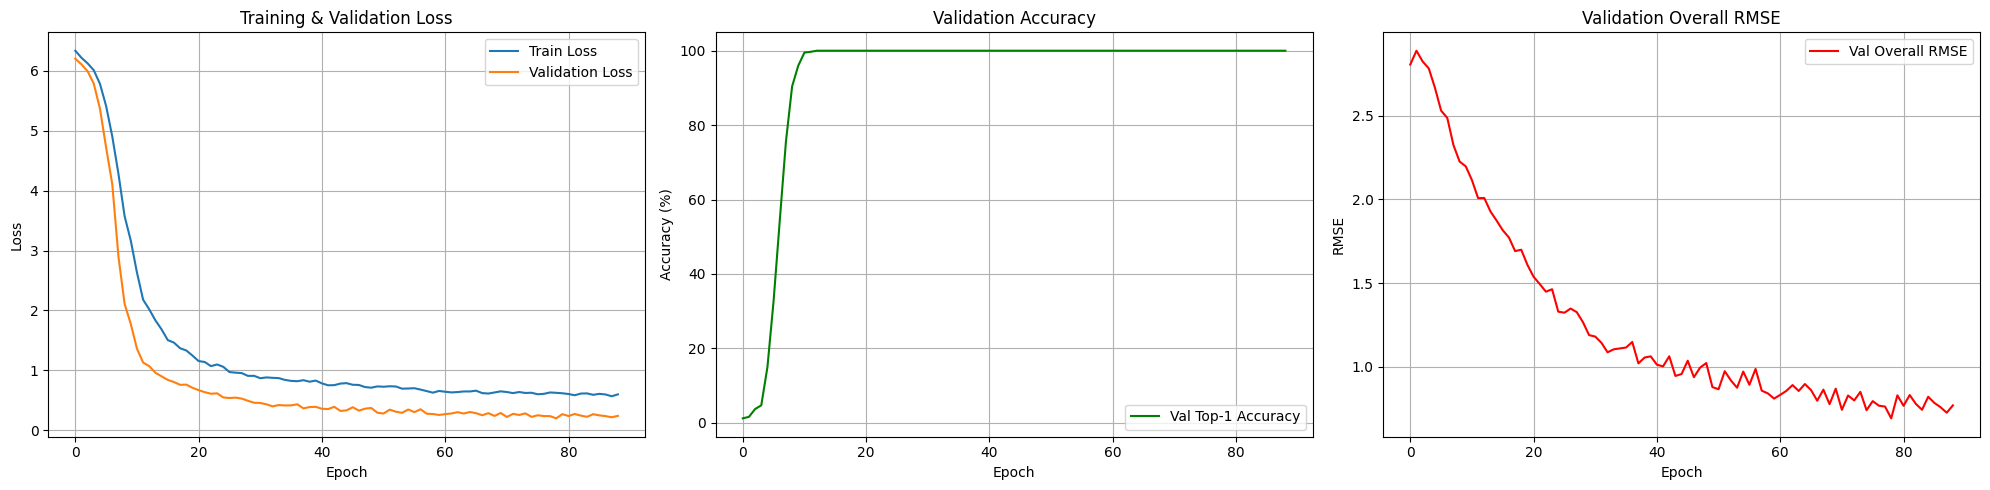

In [31]:
print("Plotting training history...")

# Create a figure with 3 subplots
plt.figure(figsize=(20, 5))

# --- Plot 1: Training & Validation Loss ---
plt.subplot(1, 3, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Plot 2: Validation Accuracy ---
plt.subplot(1, 3, 2)
plt.plot(val_cls_acc_history, label='Val Top-1 Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# --- Plot 3: Validation RMSE ---
plt.subplot(1, 3, 3)
plt.plot(val_rmse_history, label='Val Overall RMSE', color='red')
plt.title('Validation Overall RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()